# QuickBite Express - Crisis Recovery Analysis

## Notebook 2: Primary Analysis

This notebook answers the 10 primary analysis questions 
covering order trends, cancellations, delivery performance, 
ratings, sentiment, revenue impact, and customer behavior 
across pre-crisis, crisis, and recovery phases.

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE_PATH = "../data/"

orders      = pd.read_csv(BASE_PATH + "fact_orders.csv")
order_items = pd.read_csv(BASE_PATH + "fact_order_items.csv")
ratings     = pd.read_csv(BASE_PATH + "fact_ratings.csv")
delivery    = pd.read_csv(BASE_PATH + "fact_delivery_performance.csv")
customers   = pd.read_csv(BASE_PATH + "dim_customer.csv")
restaurants = pd.read_csv(BASE_PATH + "dim_restaurant.csv")
partners    = pd.read_csv(BASE_PATH + "dim_delivery_partner_.csv")
menu        = pd.read_csv(BASE_PATH + "dim_menu_item.csv")

orders['order_timestamp']   = pd.to_datetime(orders['order_timestamp'])
orders['is_cancelled_bool'] = orders['is_cancelled'] == 'Y'
orders['month']             = orders['order_timestamp'].dt.to_period('M')

def assign_phase(ts):
    if ts < pd.Timestamp('2025-06-01'):
        return 'Pre-Crisis'
    elif ts < pd.Timestamp('2025-08-01'):
        return 'Crisis'
    else:
        return 'Recovery'

orders['phase'] = orders['order_timestamp'].apply(assign_phase)
ratings         = ratings.dropna()

print("Data loaded and prepared")

Data loaded and prepared


## Q1. Monthly Order Trend - Pre-Crisis vs Crisis

Comparing total orders placed each month to measure 
the severity of decline after the crisis began in June 2025.

In [102]:
monthly_orders = orders.groupby(['month', 'phase'])['order_id'].count().reset_index()
monthly_orders.columns = ['month', 'phase', 'total_orders']

print(monthly_orders.to_string())

pre_crisis_avg = monthly_orders[monthly_orders['phase'] == 'Pre-Crisis']['total_orders'].mean()
crisis_avg     = monthly_orders[monthly_orders['phase'] == 'Crisis']['total_orders'].mean()
decline_pct    = ((pre_crisis_avg - crisis_avg) / pre_crisis_avg) * 100

print("\nPre-Crisis Monthly Average :", round(pre_crisis_avg, 0))
print("Crisis Monthly Average     :", round(crisis_avg, 0))
print("Decline Percentage         :", round(decline_pct, 2), "%")

     month       phase  total_orders
0  2025-01  Pre-Crisis         23539
1  2025-02  Pre-Crisis         22667
2  2025-03  Pre-Crisis         23543
3  2025-04  Pre-Crisis         21466
4  2025-05  Pre-Crisis         22591
5  2025-06      Crisis          9293
6  2025-07      Crisis          8818
7  2025-08    Recovery          8555
8  2025-09    Recovery          8694

Pre-Crisis Monthly Average : 22761.0
Crisis Monthly Average     : 9056.0
Decline Percentage         : 60.22 %


### Chart: Monthly Order Volume

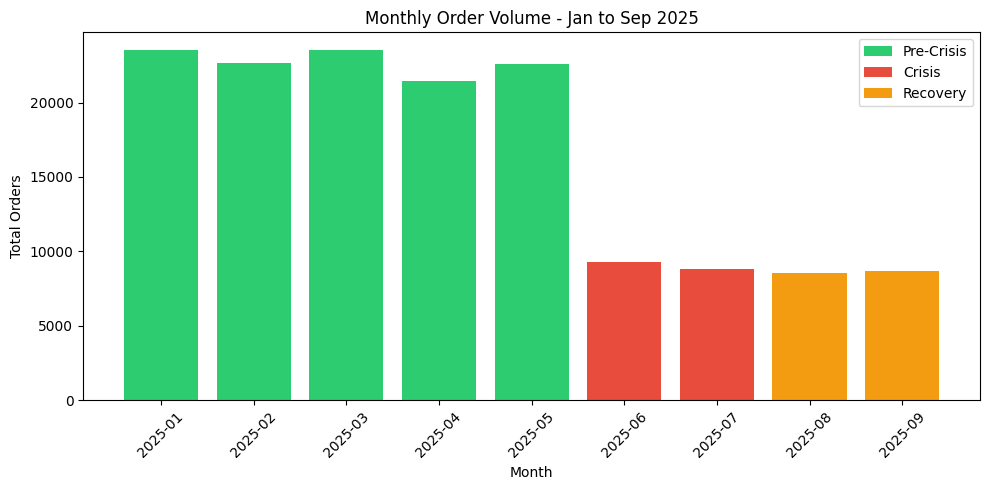

In [103]:
import os
os.makedirs('../assets', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5))

colors = []
for phase in monthly_orders['phase']:
    if phase == 'Pre-Crisis':
        colors.append('#2ecc71')
    elif phase == 'Crisis':
        colors.append('#e74c3c')
    else:
        colors.append('#f39c12')

months_str = monthly_orders['month'].astype(str)

ax.bar(months_str, monthly_orders['total_orders'], color=colors)
ax.set_title('Monthly Order Volume - Jan to Sep 2025')
ax.set_xlabel('Month')
ax.set_ylabel('Total Orders')
ax.set_xticklabels(months_str, rotation=45)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Pre-Crisis'),
    Patch(facecolor='#e74c3c', label='Crisis'),
    Patch(facecolor='#f39c12', label='Recovery')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('../assets/q1_monthly_orders.png', dpi=150)
plt.show()

### Observation

Monthly orders remained stable between 21,000 and 23,500 
during the pre-crisis period (Jan-May 2025), averaging 22,761 orders per month.

Orders dropped sharply to 9,293 in June 2025 when the crisis began, 
and further declined to 8,818 in July 2025.

The recovery phase (Aug-Sep) shows no meaningful improvement, 
with orders stabilizing around 8,600 per month.

Overall decline from pre-crisis to crisis: 60.22%
This indicates that 6 out of every 10 customers stopped ordering 
after the crisis began.

## Q2. Top 5 Cities by Order Decline

Identifying which cities were most impacted by the crisis 
by comparing order volumes in pre-crisis vs crisis period.

In [104]:
# merge orders with customers to get city information
orders_city = orders.merge(customers[['customer_id', 'city']], 
                            on='customer_id', how='left')

# count orders per city per phase
city_phase = orders_city.groupby(['city', 'phase'])['order_id'].count().reset_index()
city_phase.columns = ['city', 'phase', 'total_orders']

# separate pre-crisis and crisis
pre  = city_phase[city_phase['phase'] == 'Pre-Crisis'][['city', 'total_orders']].rename(columns={'total_orders': 'pre_crisis_orders'})
cris = city_phase[city_phase['phase'] == 'Crisis'][['city', 'total_orders']].rename(columns={'total_orders': 'crisis_orders'})

# join both
city_decline = pre.merge(cris, on='city', how='inner')

# calculate percentage decline
city_decline['decline_pct'] = ((city_decline['pre_crisis_orders'] - city_decline['crisis_orders']) / city_decline['pre_crisis_orders']) * 100
city_decline['decline_pct'] = city_decline['decline_pct'].round(2)

# top 5 cities
top5_cities = city_decline.sort_values('decline_pct', ascending=False).head(5)
print(f"Note: {orders_city['city'].isnull().sum()} orders excluded - unmatched customer_id")
print(top5_cities.to_string(index=False))

Note: 5053 orders excluded - unmatched customer_id
     city  pre_crisis_orders  crisis_orders  decline_pct
  Kolkata               7601           1144        84.95
   Mumbai              17848           2713        84.80
Bengaluru              31277           4769        84.75
    Delhi              15580           2380        84.72
     Pune               8817           1364        84.53


### Chart: Top 5 Cities by Order Decline

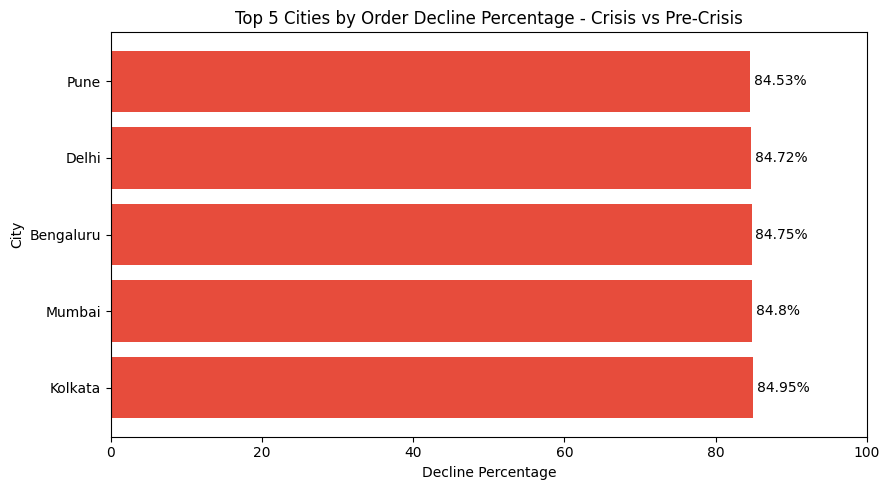

In [105]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(top5_cities['city'], top5_cities['decline_pct'], color='#e74c3c')
ax.set_title('Top 5 Cities by Order Decline Percentage - Crisis vs Pre-Crisis')
ax.set_xlabel('Decline Percentage')
ax.set_ylabel('City')
ax.set_xlim(0, 100)

for i, (val, city) in enumerate(zip(top5_cities['decline_pct'], top5_cities['city'])):
    ax.text(val + 0.5, i, f'{val}%', va='center')

plt.tight_layout()
plt.savefig('../assets/q2_city_decline.png', dpi=150)
plt.show()

## Q3. Top 10 Restaurants by Order Decline

Identifying high-volume restaurants that lost the most orders 
during the crisis. Only restaurants with at least 10 pre-crisis 
orders are considered to ensure meaningful comparison.

In [106]:
# count orders per restaurant per phase
rest_phase = orders.groupby(['restaurant_id', 'phase'])['order_id'].count().reset_index()
rest_phase.columns = ['restaurant_id', 'phase', 'total_orders']

# separate pre-crisis and crisis
rest_pre  = rest_phase[rest_phase['phase'] == 'Pre-Crisis'][['restaurant_id', 'total_orders']].rename(columns={'total_orders': 'pre_crisis_orders'})
rest_cris = rest_phase[rest_phase['phase'] == 'Crisis'][['restaurant_id', 'total_orders']].rename(columns={'total_orders': 'crisis_orders'})

# join both
rest_decline = rest_pre.merge(rest_cris, on='restaurant_id', how='inner')

# filter restaurants with at least 50 pre-crisis orders
rest_decline = rest_decline[rest_decline['pre_crisis_orders'] >= 10]

# calculate decline percentage
rest_decline['decline_pct'] = ((rest_decline['pre_crisis_orders'] - rest_decline['crisis_orders']) / rest_decline['pre_crisis_orders']) * 100
rest_decline['decline_pct'] = rest_decline['decline_pct'].round(2)

# merge with restaurant names
rest_decline = rest_decline.merge(restaurants[['restaurant_id', 'restaurant_name', 'city', 'cuisine_type']], 
                                   on='restaurant_id', how='left')

# top 10
top10_rest = rest_decline.sort_values('decline_pct', ascending=False).head(10)
print(top10_rest[['restaurant_name', 'city', 'cuisine_type', 'pre_crisis_orders', 'crisis_orders', 'decline_pct']].to_string(index=False))

            restaurant_name      city cuisine_type  pre_crisis_orders  crisis_orders  decline_pct
Hot & Crispy Express Darbar   Kolkata      Chinese                 16              1        93.75
              Sri Mess Zone      Pune North Indian                 16              1        93.75
       Fresh Kitchen Darbar    Mumbai North Indian                 15              1        93.33
          Sri Curry Central Bengaluru    Fast Food                 15              1        93.33
      Punjabi Curry Delight Bengaluru      Biryani                 15              1        93.33
   Tandoori Mess Bhojanalay Hyderabad      Biryani                 15              1        93.33
          Spicy Sweets Cafe      Pune South Indian                 15              1        93.33
         Urban Tandoor Cafe   Chennai      Biryani                 15              1        93.33
   Hot & Crispy Express Hub   Chennai North Indian                 15              1        93.33
          Delhi Swee

In [107]:
print("rest_pre rows:", len(rest_pre))
print("rest_cris rows:", len(rest_cris))
print("\nrest_pre sample:")
print(rest_pre.head(3))
print("\nrest_cris sample:")
print(rest_cris.head(3))
print("\nPhase values in orders:")
print(orders['phase'].unique())

rest_pre rows: 19919
rest_cris rows: 11947

rest_pre sample:
  restaurant_id  pre_crisis_orders
1     REST00001                  4
4     REST00002                  9
7     REST00003                  5

rest_cris sample:
  restaurant_id  crisis_orders
0     REST00001              1
3     REST00002              1
6     REST00003              1

Phase values in orders:
<StringArray>
['Pre-Crisis', 'Crisis', 'Recovery']
Length: 3, dtype: str


### Chart: Top 10 Restaurants by Order Decline

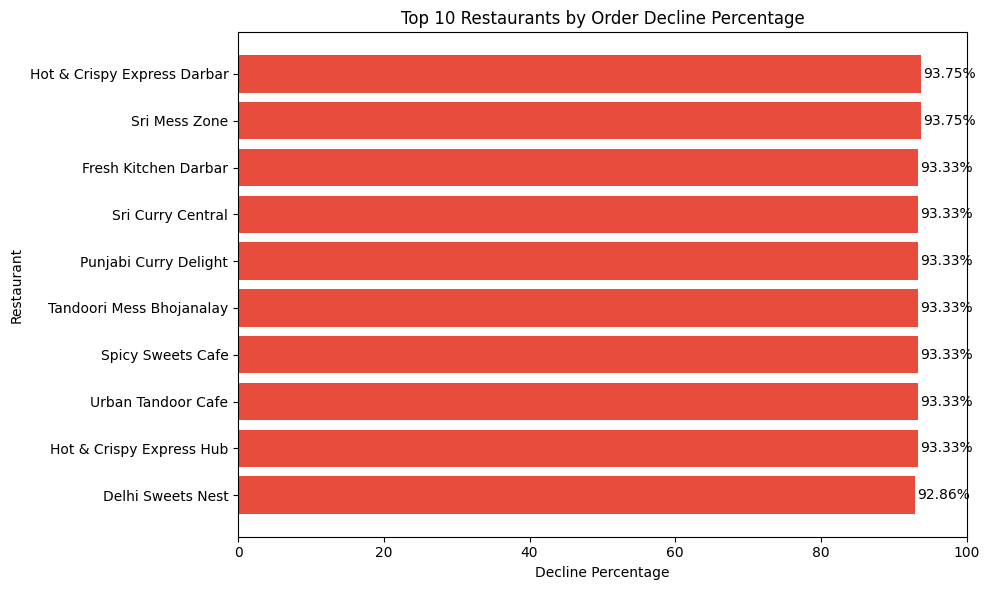

In [108]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top10_rest['restaurant_name'], top10_rest['decline_pct'], color='#e74c3c')
ax.set_title('Top 10 Restaurants by Order Decline Percentage')
ax.set_xlabel('Decline Percentage')
ax.set_ylabel('Restaurant')
ax.set_xlim(0, 100)
ax.invert_yaxis()

for i, val in enumerate(top10_rest['decline_pct']):
    ax.text(val + 0.3, i, f'{val}%', va='center')

plt.tight_layout()
plt.savefig('../assets/q3_restaurant_decline.png', dpi=150)
plt.show()

## Q4. Cancellation Rate Analysis

Analysing how cancellation rates changed across phases 
and identifying which cities had the highest cancellation rates 
during the crisis period.

In [109]:
# phase wise cancellation rate
phase_cancel = orders.groupby('phase').agg(
    total_orders    = ('order_id', 'count'),
    cancelled_orders = ('is_cancelled_bool', 'sum')
).reset_index()

phase_cancel['cancellation_rate'] = (phase_cancel['cancelled_orders'] / phase_cancel['total_orders'] * 100).round(2)

phase_order = ['Pre-Crisis', 'Crisis', 'Recovery']
phase_cancel['phase'] = pd.Categorical(phase_cancel['phase'], categories=phase_order, ordered=True)
phase_cancel = phase_cancel.sort_values('phase')

print("Phase-wise Cancellation Rate")
print(phase_cancel.to_string(index=False))

# city wise cancellation rate during crisis
orders_city = orders.merge(customers[['customer_id', 'city']], on='customer_id', how='left')

city_cancel = orders_city[orders_city['phase'] == 'Crisis'].groupby('city').agg(
    total_orders     = ('order_id', 'count'),
    cancelled_orders = ('is_cancelled_bool', 'sum')
).reset_index()

city_cancel['cancellation_rate'] = (city_cancel['cancelled_orders'] / city_cancel['total_orders'] * 100).round(2)
city_cancel = city_cancel.sort_values('cancellation_rate', ascending=False).head(8)

print("\nTop Cities by Cancellation Rate During Crisis")
print(city_cancel.to_string(index=False))

Phase-wise Cancellation Rate
     phase  total_orders  cancelled_orders  cancellation_rate
Pre-Crisis        113806              6894               6.06
    Crisis         18111              2124              11.73
  Recovery         17249              2094              12.14

Top Cities by Cancellation Rate During Crisis
     city  total_orders  cancelled_orders  cancellation_rate
  Kolkata          1144                88               7.69
  Chennai          1807               133               7.36
Hyderabad          1769               126               7.12
Ahmedabad          1199                82               6.84
   Mumbai          2713               185               6.82
Bengaluru          4769               308               6.46
    Delhi          2380               151               6.34
     Pune          1364                85               6.23


### Chart: Cancellation Rate by Phase and City

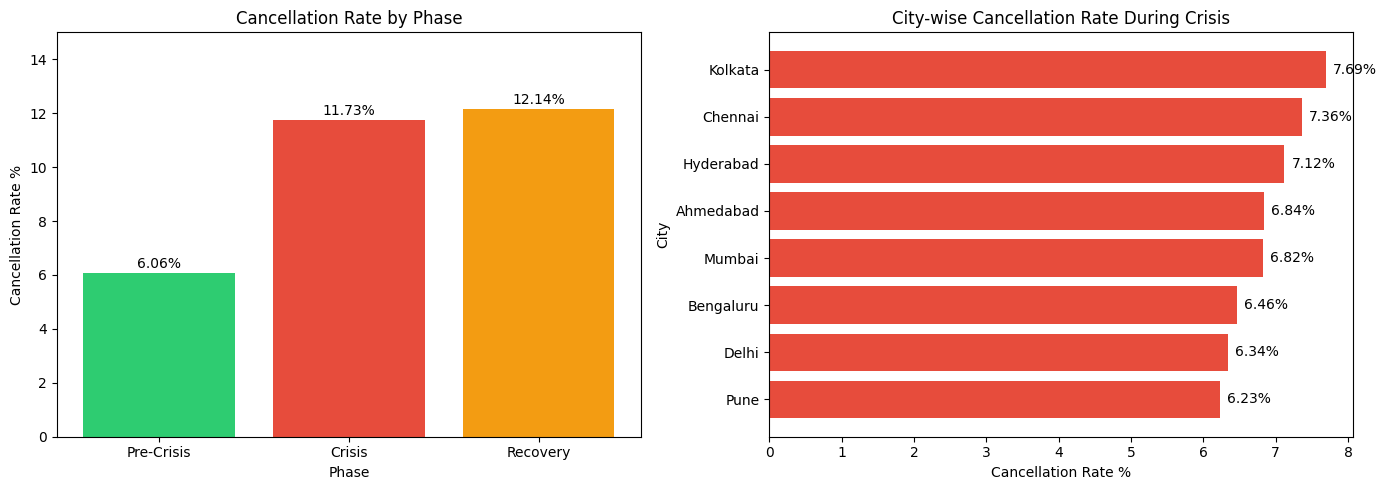

In [110]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# chart 1 - phase wise cancellation rate
colors = ['#2ecc71', '#e74c3c', '#f39c12']
ax1.bar(phase_cancel['phase'], phase_cancel['cancellation_rate'], color=colors)
ax1.set_title('Cancellation Rate by Phase')
ax1.set_xlabel('Phase')
ax1.set_ylabel('Cancellation Rate %')
ax1.set_ylim(0, 15)

for i, val in enumerate(phase_cancel['cancellation_rate']):
    ax1.text(i, val + 0.2, f'{val}%', ha='center')

# chart 2 - city wise cancellation rate during crisis
ax2.barh(city_cancel['city'], city_cancel['cancellation_rate'], color='#e74c3c')
ax2.set_title('City-wise Cancellation Rate During Crisis')
ax2.set_xlabel('Cancellation Rate %')
ax2.set_ylabel('City')
ax2.invert_yaxis()

for i, val in enumerate(city_cancel['cancellation_rate']):
    ax2.text(val + 0.1, i, f'{val}%', va='center')

plt.tight_layout()
plt.savefig('../assets/q4_cancellation_rate.png', dpi=150)
plt.show()

### Observation

Cancellation rate nearly doubled from 6.06% in pre-crisis 
to 11.73% during the crisis period.

More concerning is that the recovery phase shows a further increase 
to 12.14%, which is higher than the crisis period itself. 
This suggests that delivery and operational issues have not been 
fully resolved even after the crisis period ended.

Among cities, Kolkata has the highest cancellation rate at 7.69% 
during the crisis, followed by Chennai at 7.36% and Hyderabad at 7.12%.

These three cities should be prioritized for operational improvements 
to reduce cancellations and rebuild customer trust.

## Q5. Delivery SLA Performance

Measuring average delivery times and SLA breach rates across 
all three phases to assess whether operational performance 
worsened during and after the crisis.

A delivery is considered an SLA breach when the actual delivery 
time exceeds the expected delivery time.

In [111]:
# merge delivery with orders to get phase
delivery_phase = delivery.merge(orders[['order_id', 'phase']], 
                                 on='order_id', how='left')

# calculate delay and breach flag
delivery_phase['delay_mins']  = delivery_phase['actual_delivery_time_mins'] - delivery_phase['expected_delivery_time_mins']
delivery_phase['is_breach']   = delivery_phase['actual_delivery_time_mins'] > delivery_phase['expected_delivery_time_mins']

# phase wise summary
sla_summary = delivery_phase.groupby('phase').agg(
    avg_actual_time   = ('actual_delivery_time_mins', 'mean'),
    avg_expected_time = ('expected_delivery_time_mins', 'mean'),
    breach_rate       = ('is_breach', 'mean'),
    avg_delay_mins    = ('delay_mins', 'mean')
).reset_index()

sla_summary['breach_rate_%']  = (sla_summary['breach_rate'] * 100).round(2)
sla_summary['avg_actual_time']   = sla_summary['avg_actual_time'].round(1)
sla_summary['avg_expected_time'] = sla_summary['avg_expected_time'].round(1)
sla_summary['avg_delay_mins']    = sla_summary['avg_delay_mins'].round(1)

phase_order = ['Pre-Crisis', 'Crisis', 'Recovery']
sla_summary['phase'] = pd.Categorical(sla_summary['phase'], categories=phase_order, ordered=True)
sla_summary = sla_summary.sort_values('phase')

print(sla_summary[['phase', 'avg_actual_time', 'avg_expected_time', 'breach_rate_%', 'avg_delay_mins']].to_string(index=False))

     phase  avg_actual_time  avg_expected_time  breach_rate_%  avg_delay_mins
Pre-Crisis             39.5               37.5          56.40             2.0
    Crisis             60.1               42.5          87.84            17.6
  Recovery             60.1               42.5          87.76            17.6


### Chart: Delivery SLA Performance by Phase

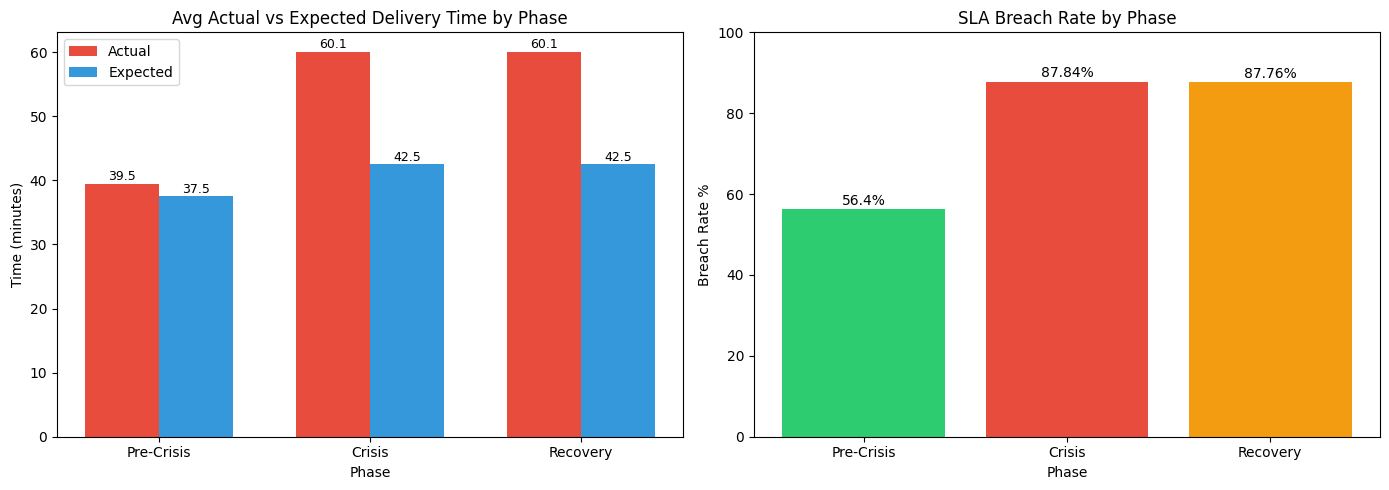

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

phases = sla_summary['phase'].astype(str)
colors = ['#2ecc71', '#e74c3c', '#f39c12']

# chart 1 - actual vs expected delivery time
x = range(len(phases))
width = 0.35

ax1.bar([i - width/2 for i in x], sla_summary['avg_actual_time'], width, label='Actual', color='#e74c3c')
ax1.bar([i + width/2 for i in x], sla_summary['avg_expected_time'], width, label='Expected', color='#3498db')
ax1.set_title('Avg Actual vs Expected Delivery Time by Phase')
ax1.set_xlabel('Phase')
ax1.set_ylabel('Time (minutes)')
ax1.set_xticks(list(x))
ax1.set_xticklabels(phases)
ax1.legend()

for i, (act, exp) in enumerate(zip(sla_summary['avg_actual_time'], sla_summary['avg_expected_time'])):
    ax1.text(i - width/2, act + 0.5, str(act), ha='center', fontsize=9)
    ax1.text(i + width/2, exp + 0.5, str(exp), ha='center', fontsize=9)

# chart 2 - sla breach rate
ax2.bar(phases, sla_summary['breach_rate_%'], color=colors)
ax2.set_title('SLA Breach Rate by Phase')
ax2.set_xlabel('Phase')
ax2.set_ylabel('Breach Rate %')
ax2.set_ylim(0, 100)

for i, val in enumerate(sla_summary['breach_rate_%']):
    ax2.text(i, val + 1, f'{val}%', ha='center')

plt.tight_layout()
plt.savefig('../assets/q5_sla_performance.png', dpi=150)
plt.show()

### Observation

Pre-crisis average delivery time was 39.5 minutes against 
an expected time of 37.5 minutes, with a breach rate of 56.4%.

During the crisis, actual delivery time jumped to 60.1 minutes 
while expected time was 42.5 minutes, pushing the breach rate 
to 87.84% and average delay to 17.6 minutes per order.

The recovery phase shows no improvement over the crisis period. 
Delivery time and breach rate remain identical to crisis levels, 
indicating that infrastructure upgrades have not yet translated 
into on-ground operational improvement.

This is a critical finding as poor delivery performance directly 
contributes to low ratings and continued customer churn 
even in the recovery phase.

It is also worth noting that even pre-crisis, 56.4% of deliveries were already breaching SLA — indicating this was a pre-existing operational weakness, not solely a crisis-driven issue.

## Q6. Monthly Rating Fluctuation

Tracking average customer ratings month by month to identify 
when the sharpest decline occurred and whether ratings 
have recovered after the crisis.

In [113]:
ratings['review_timestamp'] = pd.to_datetime(ratings['review_timestamp'], 
                                              format='mixed', dayfirst=True)
ratings['month'] = ratings['review_timestamp'].dt.to_period('M')

monthly_ratings = ratings.groupby('month').agg(
    avg_rating    = ('rating', 'mean'),
    total_reviews = ('rating', 'count')
).reset_index()

monthly_ratings['avg_rating'] = monthly_ratings['avg_rating'].round(2)
monthly_ratings['month_str']  = monthly_ratings['month'].astype(str)

print(monthly_ratings[['month_str', 'avg_rating', 'total_reviews']].to_string(index=False))

month_str  avg_rating  total_reviews
  2025-01        4.58          10939
  2025-02        4.40          10588
  2025-03        4.74          10971
  2025-04        4.30          10141
  2025-05        4.49          10605
  2025-06        2.63           4165
  2025-07        2.69           3880
  2025-08        2.40           3668
  2025-09        2.31           3868


### Chart: Monthly Average Rating

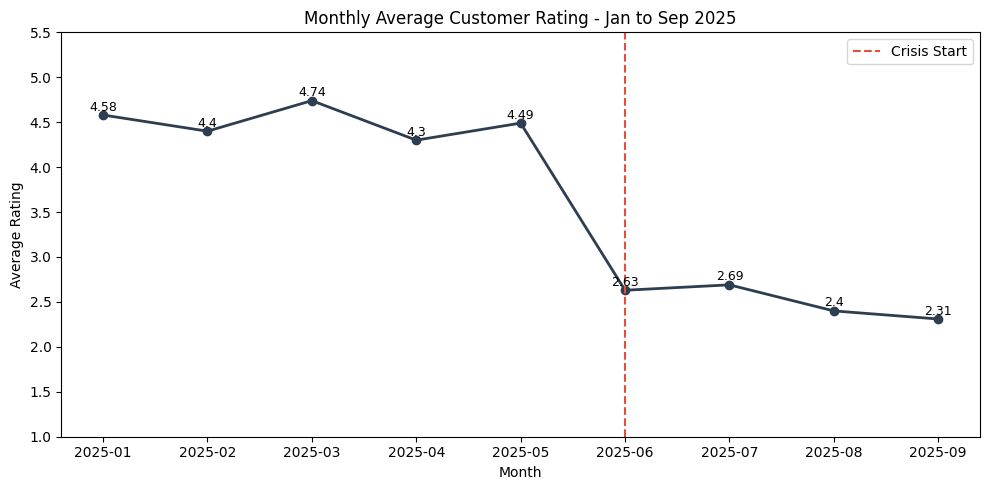

In [114]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = []
for month in monthly_ratings['month_str']:
    if month < '2025-06':
        colors.append('#2ecc71')
    elif month < '2025-08':
        colors.append('#e74c3c')
    else:
        colors.append('#f39c12')

ax.plot(monthly_ratings['month_str'], monthly_ratings['avg_rating'], 
        color='#2c3e50', linewidth=2, marker='o', markersize=6)

for i, (month, val) in enumerate(zip(monthly_ratings['month_str'], monthly_ratings['avg_rating'])):
    ax.text(i, val + 0.05, str(val), ha='center', fontsize=9)

ax.axvline(x='2025-06', color='#e74c3c', linestyle='--', linewidth=1.5, label='Crisis Start')
ax.set_title('Monthly Average Customer Rating - Jan to Sep 2025')
ax.set_xlabel('Month')
ax.set_ylabel('Average Rating')
ax.set_ylim(1, 5.5)
ax.legend()

plt.tight_layout()
plt.savefig('../assets/q6_monthly_ratings.png', dpi=150)
plt.show()

### Observation

Average customer ratings remained stable between 4.30 and 4.74 
during the pre-crisis period (Jan-May 2025).

The sharpest drop occurred in June 2025 when ratings fell from 
4.49 to 2.63, a decline of 1.86 points in a single month. 
This aligns directly with the food safety incident and 
delivery outage that began in June 2025.

Ratings continued to decline through the recovery phase, 
reaching their lowest point of 2.31 in September 2025. 
This indicates that customer satisfaction has not improved 
despite the recovery efforts, and trust has not been rebuilt.

The total review count also dropped significantly from around 
10,500 per month in pre-crisis to 3,800 per month in recovery, 
suggesting that fewer customers are engaging with the platform overall.

## Q7. Sentiment Analysis - Negative Keywords During Crisis

Extracting the most frequently used negative keywords from 
customer reviews during the crisis period to understand 
the primary reasons for customer dissatisfaction.

In [115]:
from collections import Counter
import re

stop_words = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at',
    'to', 'for', 'of', 'with', 'is', 'was', 'it', 'i', 'my',
    'very', 'so', 'this', 'that', 'not', 'no', 'be', 'are',
    'have', 'had', 'he', 'she', 'they', 'we', 'you', 'me',
    'food', 'order', 'delivery', 'ordered', 'time', 'got',
    'from', 'will', 'been', 'get', 'just', 'did', 'do', 'its'
}

negative_words = {
    'late', 'delay', 'delayed', 'cold', 'wrong', 'missing',
    'cancelled', 'cancel', 'poor', 'bad', 'worst', 'terrible',
    'horrible', 'awful', 'dirty', 'stale', 'spoiled', 'rude',
    'slow', 'never', 'disgusting', 'disappointing', 'disappointed',
    'pathetic', 'useless', 'waste', 'refund', 'unhygienic',
    'unsafe', 'sick', 'broken', 'damaged', 'spilled', 'empty',
    'unacceptable', 'undelivered', 'tasteless', 'overcooked',
    'undercooked', 'expired', 'unhelpful', 'unprofessional'
}

# filter crisis reviews with low ratings
crisis_reviews = ratings[ratings['order_id'].isin(
    orders[orders['phase'] == 'Crisis']['order_id']
)]
crisis_reviews = crisis_reviews[crisis_reviews['rating'] <= 2.5]

# extract negative keywords from review text
all_words = []
for review in crisis_reviews['review_text'].dropna():
    words = re.findall(r'\b[a-z]+\b', review.lower())
    for word in words:
        if word in negative_words:
            all_words.append(word)

word_freq = Counter(all_words)
top_keywords = pd.DataFrame(word_freq.most_common(15),
                             columns=['keyword', 'frequency'])

print(top_keywords.to_string(index=False))

 keyword  frequency
   stale        430
     bad        407
    late        361
    poor         79
    cold         67
   worst         50
terrible         34
horrible         33
   never         31


### Chart: Top Negative Keywords During Crisis

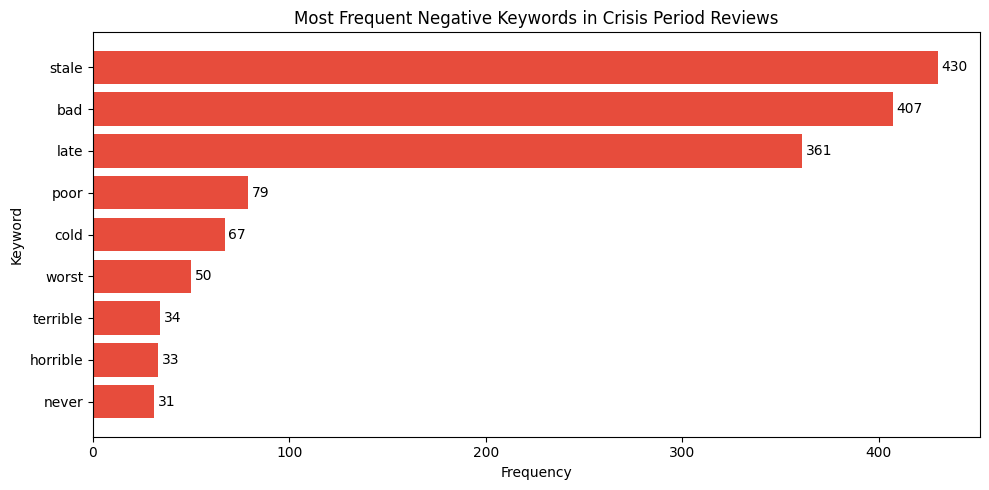

In [116]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(top_keywords['keyword'], top_keywords['frequency'], color='#e74c3c')
ax.set_title('Most Frequent Negative Keywords in Crisis Period Reviews')
ax.set_xlabel('Frequency')
ax.set_ylabel('Keyword')
ax.invert_yaxis()

for i, val in enumerate(top_keywords['frequency']):
    ax.text(val + 2, i, str(val), va='center')

plt.tight_layout()
plt.savefig('../assets/q7_negative_keywords.png', dpi=150)
plt.show()

### Observation

The most frequently used negative keyword during the crisis period 
is "stale" with 430 mentions, followed by "bad" with 407 mentions 
and "late" with 361 mentions.

This reveals two distinct problem areas that drove customer dissatisfaction.

The first is food quality. Keywords like stale, cold, bad, terrible, 
and horrible indicate that customers received food that was not fresh. 
This directly connects to the food safety incident reported in June 2025.

The second is delivery performance. Keywords like late, slow, and delay 
confirm that the delivery outage caused significant delays which 
customers noticed and complained about.

These two issues together explain the sharp rating drop seen in Q6 
and should be the primary focus areas for the recovery strategy.

## Q8. Revenue Impact Analysis

Estimating the revenue loss caused by the crisis by comparing 
total revenue, average order value, and discount patterns 
across all three phases.

In [117]:
revenue_summary = orders[orders['is_cancelled_bool'] == False].groupby('phase').agg(
    total_orders      = ('order_id', 'count'),
    total_subtotal    = ('subtotal_amount', 'sum'),
    total_discount    = ('discount_amount', 'sum'),
    total_delivery    = ('delivery_fee', 'sum'),
    total_revenue     = ('total_amount', 'sum'),
    avg_order_value   = ('total_amount', 'mean')
).reset_index()

revenue_summary['total_revenue']   = revenue_summary['total_revenue'].round(2)
revenue_summary['avg_order_value'] = revenue_summary['avg_order_value'].round(2)
revenue_summary['total_discount']  = revenue_summary['total_discount'].round(2)

phase_order = ['Pre-Crisis', 'Crisis', 'Recovery']
revenue_summary['phase'] = pd.Categorical(revenue_summary['phase'], 
                                           categories=phase_order, ordered=True)
revenue_summary = revenue_summary.sort_values('phase')

print(revenue_summary[['phase', 'total_orders', 'total_revenue', 
                         'avg_order_value', 'total_discount']].to_string(index=False))

# monthly average revenue per phase
pre_monthly_avg   = revenue_summary[revenue_summary['phase'] == 'Pre-Crisis']['total_revenue'].values[0] / 5
crisis_monthly    = revenue_summary[revenue_summary['phase'] == 'Crisis']['total_revenue'].values[0] / 2
monthly_loss      = pre_monthly_avg - crisis_monthly
total_loss        = monthly_loss * 2

print("\nPre-Crisis Monthly Avg Revenue  : Rs.", round(pre_monthly_avg, 2))
print("Crisis Monthly Avg Revenue      : Rs.", round(crisis_monthly, 2))
print("Monthly Revenue Loss            : Rs.", round(monthly_loss, 2))
print("Estimated Total Crisis Loss     : Rs.", round(total_loss, 2))

     phase  total_orders  total_revenue  avg_order_value  total_discount
Pre-Crisis        106912    37620964.25           351.89      2190304.60
    Crisis         15987     5612490.20           351.07       324966.40
  Recovery         15155     5327661.11           351.54       302711.77

Pre-Crisis Monthly Avg Revenue  : Rs. 7524192.85
Crisis Monthly Avg Revenue      : Rs. 2806245.1
Monthly Revenue Loss            : Rs. 4717947.75
Estimated Total Crisis Loss     : Rs. 9435895.5


### Chart: Revenue Comparison by Phase

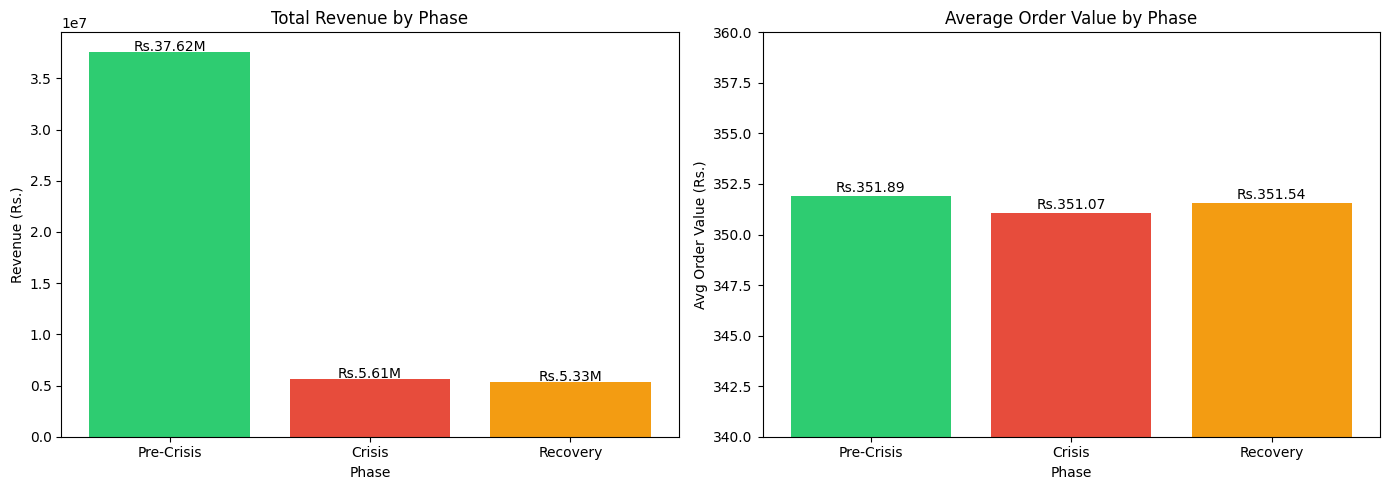

In [118]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c', '#f39c12']

ax1.bar(revenue_summary['phase'], revenue_summary['total_revenue'], color=colors)
ax1.set_title('Total Revenue by Phase')
ax1.set_xlabel('Phase')
ax1.set_ylabel('Revenue (Rs.)')

for i, val in enumerate(revenue_summary['total_revenue']):
    ax1.text(i, val + 100000, f'Rs.{val/1000000:.2f}M', ha='center')

ax2.bar(revenue_summary['phase'], revenue_summary['avg_order_value'], color=colors)
ax2.set_title('Average Order Value by Phase')
ax2.set_xlabel('Phase')
ax2.set_ylabel('Avg Order Value (Rs.)')
ax2.set_ylim(340, 360)

for i, val in enumerate(revenue_summary['avg_order_value']):
    ax2.text(i, val + 0.2, f'Rs.{val}', ha='center')

plt.tight_layout()
plt.savefig('../assets/q8_revenue_impact.png', dpi=150)
plt.show()

### Observation

Total revenue dropped from Rs. 37.6 million in the pre-crisis period 
(5 months) to Rs. 5.6 million in the crisis period (2 months).

On a monthly basis, pre-crisis revenue averaged Rs. 7.52 million 
per month while crisis monthly revenue was Rs. 2.80 million, 
representing a monthly loss of Rs. 4.71 million.

The estimated total revenue loss over the 2 month crisis period 
is Rs. 9.44 million.

Interestingly, the average order value remained stable at around 
Rs. 351 across all three phases. This indicates that customers who 
continued ordering did not reduce their spend per order. 
The revenue loss was driven entirely by the drop in order volume, 
not by customers placing smaller orders.

This is an important insight for the recovery strategy as it suggests 
that winning back lost customers, rather than increasing order value, 
should be the primary focus.

## Q9. Loyalty Impact Analysis

Identifying loyal customers who were active before the crisis 
and measuring how many completely stopped ordering during the crisis period.
Among those who churned, finding how many were highly satisfied 
customers with an average rating above 4.5.

In [119]:
# find customers with 5 or more orders in pre-crisis
pre_crisis_orders = orders[orders['phase'] == 'Pre-Crisis']

loyal_customers = pre_crisis_orders.groupby('customer_id')['order_id'].count().reset_index()
loyal_customers.columns = ['customer_id', 'pre_crisis_order_count']
loyal_customers = loyal_customers[loyal_customers['pre_crisis_order_count'] >= 2]

print("Repeat customers (2+ pre-crisis orders):", len(loyal_customers))

# find how many of these placed zero orders during crisis
crisis_orders = orders[orders['phase'] == 'Crisis']
crisis_customer_ids = set(crisis_orders['customer_id'].unique())

loyal_customers['ordered_in_crisis'] = loyal_customers['customer_id'].isin(crisis_customer_ids)
churned_loyal = loyal_customers[loyal_customers['ordered_in_crisis'] == False]

print("Churned repeat customers            :", len(churned_loyal))

# among churned, how many had avg rating above 4.5 in pre-crisis
pre_crisis_ratings = ratings[ratings['order_id'].isin(pre_crisis_orders['order_id'])]

customer_avg_rating = pre_crisis_ratings.groupby('customer_id')['rating'].mean().reset_index()
customer_avg_rating.columns = ['customer_id', 'avg_pre_crisis_rating']

churned_with_rating = churned_loyal.merge(customer_avg_rating, on='customer_id', how='left')
high_rated_churned  = churned_with_rating[churned_with_rating['avg_pre_crisis_rating'] > 4.5]

print("Churned repeat customers with avg rating above 4.5:", len(high_rated_churned))
print("Average pre-crisis rating of churned loyal customers:", 
      round(churned_with_rating['avg_pre_crisis_rating'].mean(), 2))

Repeat customers (2+ pre-crisis orders): 22342
Churned repeat customers            : 20437
Churned repeat customers with avg rating above 4.5: 7250
Average pre-crisis rating of churned loyal customers: 4.5


### Chart: Loyalty Impact

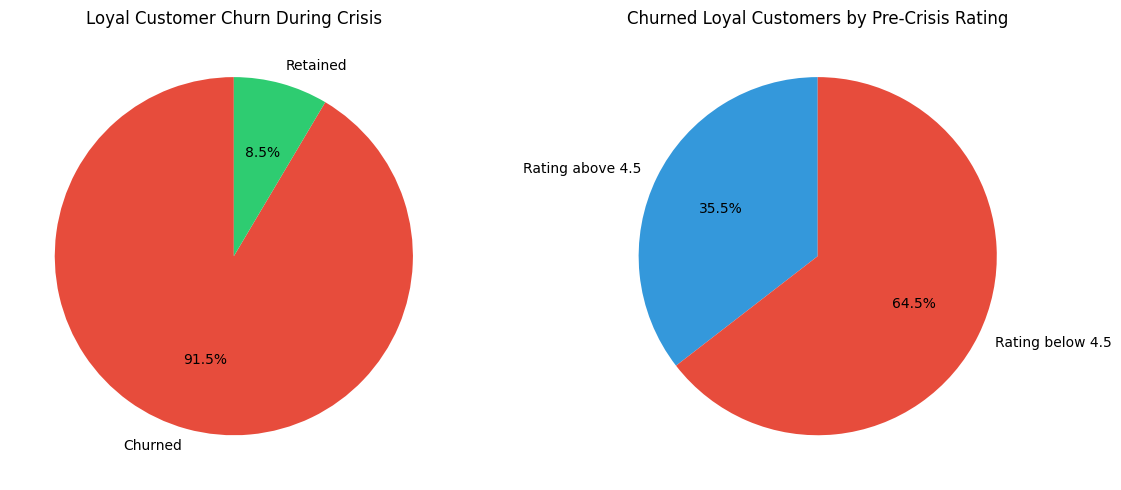

In [120]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# chart 1 - loyal customer churn
labels1 = ['Churned', 'Retained']
values1 = [len(churned_loyal), len(loyal_customers) - len(churned_loyal)]
colors1 = ['#e74c3c', '#2ecc71']
ax1.pie(values1, labels=labels1, colors=colors1, autopct='%1.1f%%', startangle=90)
ax1.set_title('Loyal Customer Churn During Crisis')

# chart 2 - churned customers by rating
labels2 = ['Rating above 4.5', 'Rating below 4.5']
values2 = [len(high_rated_churned), len(churned_with_rating) - len(high_rated_churned)]
colors2 = ['#3498db', '#e74c3c']
ax2.pie(values2, labels=labels2, colors=colors2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Churned Loyal Customers by Pre-Crisis Rating')

plt.tight_layout()
plt.savefig('../assets/q9_loyalty_impact.png', dpi=150)
plt.show()

### Observation

Out of 22,342 repeat customers (2+ pre-crisis orders), 20,437 placed 
zero orders during the crisis period, representing a 91.48% churn rate.

Among the churned repeat customers, 7,250 had an average pre-crisis 
rating above 4.5, confirming they were highly satisfied with the 
platform before the crisis and left specifically due to the June 2025 
events, not due to platform dissatisfaction.

The average pre-crisis rating of all churned repeat customers was 4.5, 
indicating that QuickBite lost a large base of genuinely happy customers 
to the crisis.

This segment represents the highest recovery opportunity. These customers 
already trusted the platform, ordered more than once, and rated it highly. 
With the right win-back campaign, a significant portion of these 7,250 
high-rated churned customers can be re-engaged through personalized 
offers targeting their preferred cuisines and cities.

## Q10. High-Value Customer Decline Analysis

Identifying the top 5% customers by pre-crisis spending and 
analysing their behavior during the crisis. Looking for common 
patterns in location, cuisine preference, and delivery experience.

In [121]:
# total spend per customer in pre-crisis
pre_spend = orders[
    (orders['phase'] == 'Pre-Crisis') & 
    (orders['is_cancelled_bool'] == False)
].groupby('customer_id').agg(
    total_spend       = ('total_amount', 'sum'),
    order_count       = ('order_id', 'count')
).reset_index()

# top 5% by spend
threshold = pre_spend['total_spend'].quantile(0.95)
high_value = pre_spend[pre_spend['total_spend'] >= threshold].copy()
print("Top 5% spend threshold : Rs.", round(threshold, 2))
print("High value customers   :", len(high_value))

# their crisis order count
crisis_spend = orders[
    (orders['phase'] == 'Crisis') & 
    (orders['is_cancelled_bool'] == False)
].groupby('customer_id').agg(
    crisis_order_count = ('order_id', 'count')
).reset_index()

high_value = high_value.merge(crisis_spend, on='customer_id', how='left')
high_value['crisis_order_count'] = high_value['crisis_order_count'].fillna(0)
high_value['order_drop'] = high_value['order_count'] - high_value['crisis_order_count']

# their pre-crisis and crisis ratings
pre_ratings = ratings[ratings['order_id'].isin(
    orders[(orders['phase'] == 'Pre-Crisis')]['order_id']
)].groupby('customer_id')['rating'].mean().reset_index()
pre_ratings.columns = ['customer_id', 'pre_crisis_rating']

crisis_ratings = ratings[ratings['order_id'].isin(
    orders[(orders['phase'] == 'Crisis')]['order_id']
)].groupby('customer_id')['rating'].mean().reset_index()
crisis_ratings.columns = ['customer_id', 'crisis_rating']

high_value = high_value.merge(pre_ratings, on='customer_id', how='left')
high_value = high_value.merge(crisis_ratings, on='customer_id', how='left')
high_value['rating_drop'] = high_value['pre_crisis_rating'] - high_value['crisis_rating']

print("\nHigh Value Customer Summary")
print(high_value[['customer_id', 'total_spend', 'order_count', 
                   'crisis_order_count', 'order_drop', 
                   'pre_crisis_rating', 'crisis_rating']].head(10).to_string(index=False))

Top 5% spend threshold : Rs. 932.88
High value customers   : 4144

High Value Customer Summary
customer_id  total_spend  order_count  crisis_order_count  order_drop  pre_crisis_rating  crisis_rating
 CUST000020      1139.18            3                 0.0         3.0               4.55            NaN
 CUST000088      1340.03            3                 0.0         3.0               4.60            NaN
 CUST000190      1026.29            2                 0.0         2.0               4.70            NaN
 CUST000269      1132.03            3                 0.0         3.0               4.40            NaN
 CUST000394      1082.22            2                 0.0         2.0               4.10            NaN
 CUST000443       987.07            2                 0.0         2.0               4.00            NaN
 CUST000452      1024.31            3                 0.0         3.0               4.30            NaN
 CUST000586      1097.42            3                 0.0         3.0    

In [122]:
# add city and cuisine patterns
high_value_city = high_value.merge(
    customers[['customer_id', 'city', 'acquisition_channel']], 
    on='customer_id', how='left'
)

# most common orders in pre-crisis for these customers
pre_orders_hv = orders[
    (orders['phase'] == 'Pre-Crisis') & 
    (orders['customer_id'].isin(high_value['customer_id']))
]

hv_with_rest = pre_orders_hv.merge(
    restaurants[['restaurant_id', 'cuisine_type']], 
    on='restaurant_id', how='left'
)

print("High Value Customer - City Distribution")
print(high_value_city['city'].value_counts().head(6).to_string())

print("\nHigh Value Customer - Acquisition Channel")
print(high_value_city['acquisition_channel'].value_counts().to_string())

print("\nHigh Value Customer - Preferred Cuisine")
print(hv_with_rest['cuisine_type'].value_counts().head(6).to_string())

print("\nCustomers with zero crisis orders:", 
      len(high_value[high_value['crisis_order_count'] == 0]))

print("Customers with zero crisis orders %:", 
      round(len(high_value[high_value['crisis_order_count'] == 0]) / len(high_value) * 100, 2))

print("\nAvg pre-crisis rating of high value customers:", 
      round(high_value['pre_crisis_rating'].mean(), 2))

High Value Customer - City Distribution
city
Bengaluru    1208
Mumbai        709
Delhi         568
Chennai       407
Hyderabad     381
Pune          319

High Value Customer - Acquisition Channel
acquisition_channel
Organic     2234
Paid         846
Referral     644
Social       420

High Value Customer - Preferred Cuisine
cuisine_type
North Indian    2239
Biryani         1736
Chinese         1704
South Indian    1665
Pizza           1435
Fast Food       1089

Customers with zero crisis orders: 3823
Customers with zero crisis orders %: 92.25

Avg pre-crisis rating of high value customers: 4.51


### Chart: High Value Customer Patterns

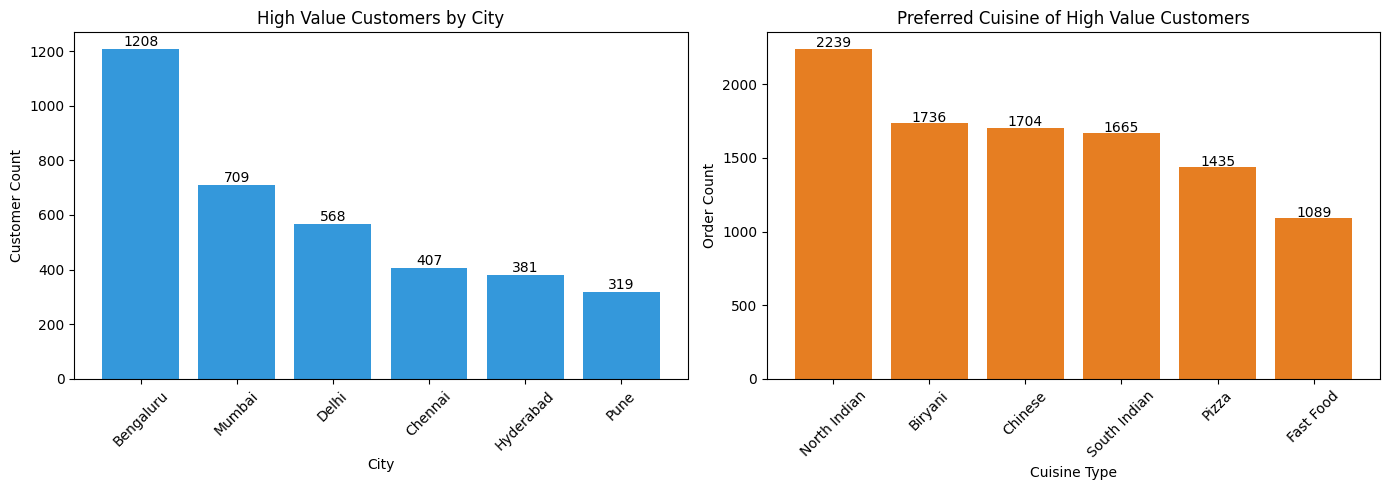

In [123]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

city_counts = high_value_city['city'].value_counts().head(6)
ax1.bar(city_counts.index, city_counts.values, color='#3498db')
ax1.set_title('High Value Customers by City')
ax1.set_xlabel('City')
ax1.set_ylabel('Customer Count')
ax1.tick_params(axis='x', rotation=45)

for i, val in enumerate(city_counts.values):
    ax1.text(i, val + 10, str(val), ha='center')

cuisine_counts = hv_with_rest['cuisine_type'].value_counts().head(6)
ax2.bar(cuisine_counts.index, cuisine_counts.values, color='#e67e22')
ax2.set_title('Preferred Cuisine of High Value Customers')
ax2.set_xlabel('Cuisine Type')
ax2.set_ylabel('Order Count')
ax2.tick_params(axis='x', rotation=45)

for i, val in enumerate(cuisine_counts.values):
    ax2.text(i, val + 10, str(val), ha='center')

plt.tight_layout()
plt.savefig('../assets/q10_high_value_customers.png', dpi=150)
plt.show()

### Observation

Out of 4,144 high value customers who spent above Rs. 932 
in the pre-crisis period, 3,823 placed zero orders during 
the crisis, representing a 92.25% churn rate.

These customers had an average pre-crisis rating of 4.51, 
confirming they were satisfied with the platform before the crisis.

Common patterns among high value customers:

City: Bengaluru accounts for the largest share with 1,208 high value 
customers, followed by Mumbai with 709 and Delhi with 568. 
These three cities alone represent 60% of all high value customers 
and should be the primary focus for recovery campaigns.

Acquisition Channel: 2,234 high value customers came through organic 
channels, meaning they discovered QuickBite on their own without 
paid advertising. These customers tend to have stronger platform 
loyalty and higher recovery potential.

Cuisine Preference: North Indian, Biryani, and Chinese are the top 
three preferred cuisines among high value customers. Recovery campaigns 
featuring these cuisine categories are likely to drive higher engagement.

These customers represent the highest revenue recovery opportunity 
and should be targeted with personalized win-back campaigns.

## Primary Analysis Summary

All 10 primary questions have been analysed across the three 
business phases of Pre-Crisis, Crisis, and Recovery.

Key findings:

Order volume declined 60.22% from a monthly average of 22,761 
in pre-crisis to 9,056 during the crisis period.

All major cities experienced an 84 to 85% decline in orders, 
indicating a platform-wide impact rather than a regional issue.

Cancellation rate nearly doubled from 6.06% to 11.73% and 
continued rising to 12.14% in the recovery phase.

SLA breach rate jumped from 56.4% to 87.84% during the crisis 
and has not improved in the recovery phase.

Average customer rating dropped from 4.49 in May 2025 to 2.63 
in June 2025 and continued declining to 2.31 in September 2025.

The most common negative keywords in crisis reviews were stale, 
bad, and late, pointing to food quality and delivery as the 
two primary complaint areas.

Estimated revenue loss over the 2 month crisis period is 
Rs. 9.44 million.

91.48% of repeat customers (2+ pre-crisis orders) and 92.25% of high value customers stopped ordering during the crisis, representing the highest priority segment for recovery campaigns